## Load in the Benchmarking Outputs

In [1]:
library(dplyr)
library(ggplot2)
library(jsonlite)
library(magrittr)
library(purrr)
library(readr)
library(stringr)
library(tibble)
library(tidyr)
library(here)

inp <- list(
  sim_info_dir = here("data", "pge-tools-benchmark", "simulations", "SpotMalaria"), 
  tool_res_dir = here("data", "pge-tools-benchmark", "tool_results", "FEM"), 
  tool_params = here("data", "pge-tools-benchmark", "tool_results", "FEM", "tool_params.json")
)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:magrittr’:

    set_names


The following object is masked from ‘package:jsonlite’:

    flatten



Attaching package: ‘tidyr’


The following object is masked from ‘package:magrittr’:

    extract


here() starts at /Users/kmurie/Documents/git_projects/PGEforge



First, all of the tool results, tool parameters, expected simulated values, and
simulation parameters are read into a tibble.

In [2]:
# Read all expected frequencies into one tibble ------------------------
sim_truth <- tibble(
    sim_truth_path = list.files(
      inp$sim_info_dir, 
      pattern = "population_aa_multiloci_variants_freqs_prevs.tsv.gz", 
      full.names = TRUE, 
      recursive = TRUE
    )
  ) %>%
  mutate(
    sim_truth = map(
      sim_truth_path, 
      read_tsv, 
      col_types = cols(
        .default = col_integer(), 
        population_name = col_character(), 
        country = col_character(), 
        variant = col_character(), 
        freq = col_double(), 
        prev = col_double(), 
        group_id = col_character()
      ), 
      progress = FALSE
    )
  ) %>%
  select(-sim_truth_path) %>%
  unnest(sim_truth) %>%
  rename(
    sim_id = population_name, 
    exp_freq = freq, 
    exp_prev = prev, 
    exp_n_samp = sample_count
  ) %>%
  select(
    -pop, 
    -country, 
    -aas_in_variant, 
    -allele_count, 
    -total_samples, 
    -total_alleles
  )

# Read in all simulation parameters into one tibble --------------------
sim_params <- tibble(
    sim_params_path = list.files(
      inp$sim_info_dir, 
      pattern = "simulation_parameters.json", 
      full.names = TRUE, 
      recursive = TRUE
    )
  ) %>%
  mutate(
    sim_params = map(
      sim_params_path, 
      jsonlite::fromJSON
    )
  ) %>%
  select(-sim_params_path) %>%
  mutate(sim_params = map(sim_params, as_tibble)) %>%
  unnest(sim_params) %>%
  select(
    -collection_year, 
    -obs_freq_monoclonal, 
    -obs_non_recombinant, 
    -mean_k, 
    -sample_count, 
    -est_between_sample_relatedness
  ) %>%
  rename(
    sim_id = population_name, 
    true_mean_coi = mean_coi
  )
# sim_truth <- sim_truth %>%
#   left_join(sim_params, by = "sim_id")

# Read in all FEM results into one tibble ------------------------------
tool_results <- tibble(
    tool_res_path = list.files(
      inp$tool_res_dir, 
      pattern = "*.tsv.gz", 
      full.names = TRUE, 
      recursive = TRUE
    )
  ) %>%
  mutate(tool_res_dir = dirname(tool_res_path)) %>%
  mutate(sim_id = basename(dirname(tool_res_dir))) %>%
  mutate(paramset_id = basename(tool_res_dir)) %>%
  select(-tool_res_dir) %>%
  mutate(
    tool_res = map(
      tool_res_path, 
      read_tsv, 
      col_types = cols(
        .default = col_double(), 
        sequence = col_character(), 
        variant = col_character(), 
        sample_total = col_integer(), 
        group_id = col_character()
      ), 
      progress = FALSE
    )
  ) %>%
  select(-tool_res_path) %>%
  unnest(tool_res) %>%
  rename(
    obs_freq = freq, 
    obs_prev = prev, 
    obs_n_samp = sample_total
  ) %>%
  select(-sequence, -median_freq, -`CI_2.5`, -`CI_97.5`)

# Read in tool parameters, and join ------------------------------------
tool_params <- jsonlite::fromJSON(inp$tool_params) %>%
  as_tibble() %>%
  mutate(mean_coi_tool_param = paramset$coi) %>%
  select(-loci_groups, -paramset)

In [3]:
# create a sim truth for every combo of params tool was run with 
# sim_truth, tool_params, tool_results, sim_params

# Add dummy key to both
sim_truth$key <- 1
tool_params$key <- 1

# Merge on the key (cross join)
result <- merge(sim_truth, tool_params, by = "key")

# Drop the key
result$key <- NULL

In [4]:
head(result)

,sim_id,variant,exp_n_samp,exp_freq,exp_prev,group_id,paramset_id,mean_coi_tool_param
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<int>
1,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset1,1
2,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset2,3
3,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset3,5
4,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset1,1
5,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset2,3
6,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset3,5


In [5]:
tool_results<- merge(tool_results, tool_params, by="paramset_id")
tool_results_wtruth <- result %>%
  # Use an inner join because FEM also estimates frequencies for 
  # subsets of the requested multilocus genotypes, and these 
  # frequencies are not benchmarked
  full_join(tool_results, by = c("sim_id", "paramset_id","variant", "group_id","mean_coi_tool_param"))

In [6]:
tool_results_wtruth <- merge(tool_results_wtruth, sim_params)

In [7]:
head(tool_results_wtruth)

,sim_id,variant,exp_n_samp,exp_freq,exp_prev,group_id,paramset_id,mean_coi_tool_param,obs_freq,obs_prev,obs_n_samp,key,country,pop_alpha,coi_r,coi_p,k_s,true_mean_coi
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset1,1,0.09862134,0.1288433,100,1,Cambodia,99,0.25,0.7,0.5,1.33
2,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset2,3,0.09084855,0.1273480,100,1,Cambodia,99,0.25,0.7,0.5,1.33
3,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset3,5,0.08731617,0.1315140,100,1,Cambodia,99,0.25,0.7,0.5,1.33
4,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset1,1,0.16364295,0.2134280,100,1,Cambodia,99,0.25,0.7,0.5,1.33
5,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset2,3,0.18079054,0.2307553,100,1,Cambodia,99,0.25,0.7,0.5,1.33
6,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset3,5,0.20040304,0.2436733,100,1,Cambodia,99,0.25,0.7,0.5,1.33


In [8]:
# Classification of tp, fp, fn 
tool_results_wtruth <- tool_results_wtruth %>%
  mutate(classification = case_when(
    !is.na(exp_freq) & !is.na(obs_freq) ~ "tp",
    is.na(exp_freq)  & !is.na(obs_freq) ~ "fp",
    !is.na(exp_freq) &  is.na(obs_freq) ~ "fn",
    TRUE ~ NA_character_
  ))

In [9]:
tool_results_wtruth <- tool_results_wtruth %>%
  mutate(across(everything(), ~ replace_na(., 0)))

## Statistics 

In [10]:
# (obs_freq-exp_freq)/root(obs_freq(1-obs_freq)+exp_freq(1-exp_freq))

In [11]:
tool_results_wtruth <- tool_results_wtruth %>%
  mutate(p = (obs_freq - exp_freq) /
           sqrt(obs_freq * (1 - obs_freq) + exp_freq * (1 - exp_freq)))

In [12]:
head(tool_results_wtruth)

,sim_id,variant,exp_n_samp,exp_freq,exp_prev,group_id,paramset_id,mean_coi_tool_param,obs_freq,obs_prev,obs_n_samp,key,country,pop_alpha,coi_r,coi_p,k_s,true_mean_coi,classification,p
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset1,1,0.09862134,0.1288433,100,1,Cambodia,99,0.25,0.7,0.5,1.33,tp,0.074133128
2,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset2,3,0.09084855,0.1273480,100,1,Cambodia,99,0.25,0.7,0.5,1.33,tp,0.055450744
3,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:I,8,0.06956522,0.09756098,six_med_div,fem_paramset3,5,0.08731617,0.1315140,100,1,Cambodia,99,0.25,0.7,0.5,1.33,tp,0.046710142
4,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset1,1,0.16364295,0.2134280,100,1,Cambodia,99,0.25,0.7,0.5,1.33,tp,-0.003003528
5,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset2,3,0.18079054,0.2307553,100,1,Cambodia,99,0.25,0.7,0.5,1.33,tp,0.029118814
6,simulated_Cambodia_pop_001,PF3D7_0104100.1:714:D;PF3D7_0731500.1:401:I;PF3D7_0824200.1:474:I;PF3D7_1121800.1:240:E;PF3D7_1335900.1:128:Y;PF3D7_1464700.1:238:M,15,0.16521739,0.18292683,six_med_div,fem_paramset3,5,0.20040304,0.2436733,100,1,Cambodia,99,0.25,0.7,0.5,1.33,tp,0.064437575


## Bland-Altman Plot 

In [13]:
tool_results_wtruth <- tool_results_wtruth %>%
  mutate(mean_freqs = rowMeans(across(c(obs_freq, exp_freq)), na.rm = TRUE))

In [14]:
tool_results_wtruth <- tool_results_wtruth %>%
  mutate(diff_freq = (obs_freq - exp_freq))

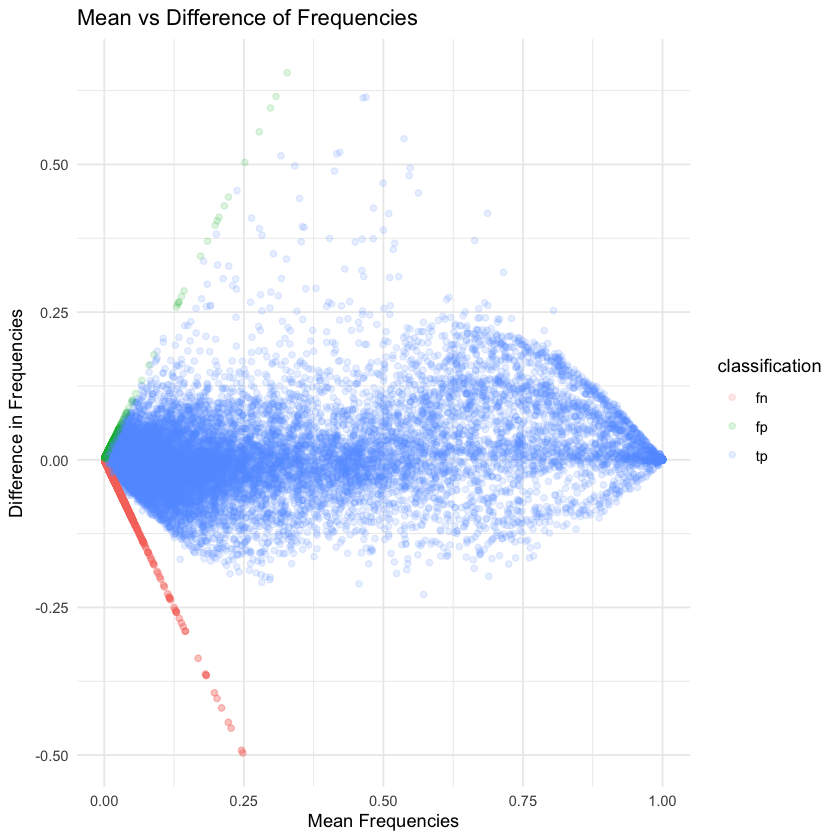

In [15]:
ggplot(tool_results_wtruth, aes(x = mean_freqs, y = diff_freq, color = classification)) +
  geom_point(alpha= 0.15) +
  labs(
    x = "Mean Frequencies",
    y = "Difference in Frequencies",
    title = "Mean vs Difference of Frequencies"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


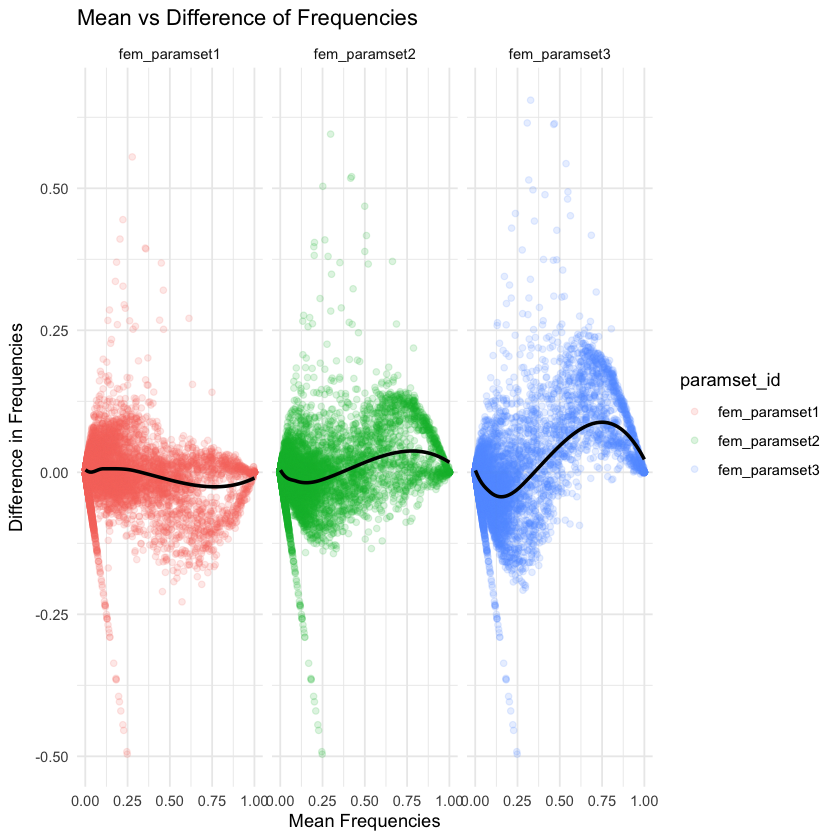

In [27]:
ggplot(tool_results_wtruth, aes(x = mean_freqs, y = diff_freq, color = paramset_id)) +
  geom_point(alpha= 0.15) +
  geom_smooth(method = "loess", color = "black")+
  labs(
    x = "Mean Frequencies",
    y = "Difference in Frequencies",
    title = "Mean vs Difference of Frequencies"
  ) +
  facet_wrap(~paramset_id) + 
  theme_minimal()

In [19]:
tool_params

paramset_id,mean_coi_tool_param,key
<chr>,<int>,<dbl>
fem_paramset1,1,1
fem_paramset2,3,1
fem_paramset3,5,1


## Performance with Good COI Specification

Next, performance is assessed when the specified COI is close to the true COI.
This is done by finding the set of tool results for each simulation where the
COI parameter was set the closest to the true COI.

In [26]:
# Filter so that FEM COI parameter was close to the true mean COI -----
tool_results_wtruth_goodcoi <- tool_results_wtruth %>%
  mutate(coi_misspec = mean_coi_tool_param - true_mean_coi) %>%
  group_by(sim_id, paramset_id, variant, group_id) %>%
  filter(coi_misspec == min(abs(coi_misspec))) %>%
  ungroup()

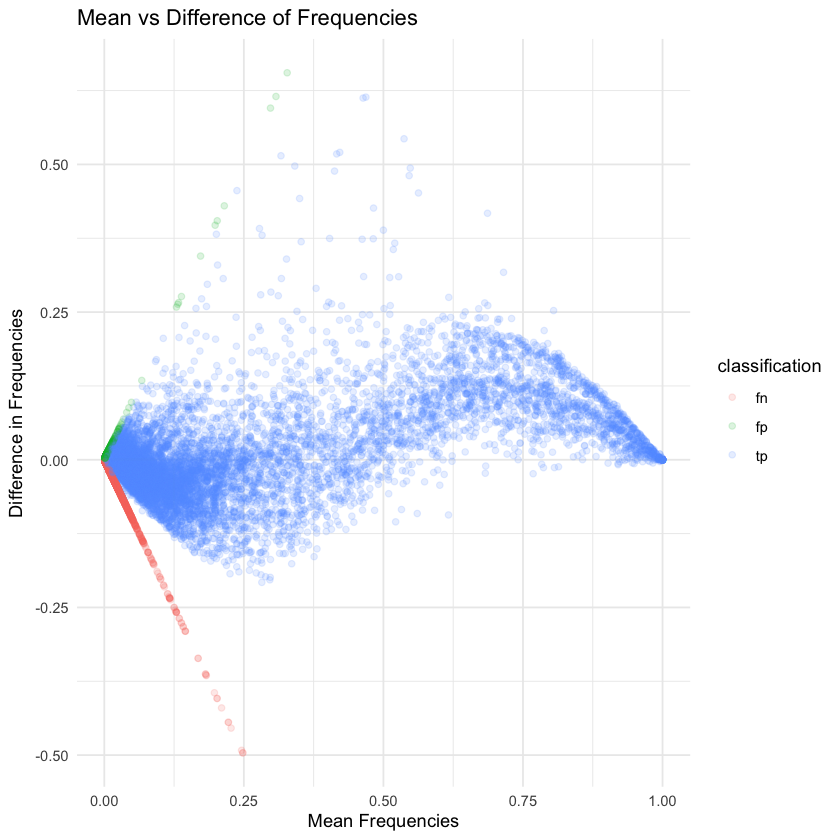

In [27]:
ggplot(tool_results_wtruth_goodcoi, aes(x = mean_freqs, y = diff_freq, color = classification)) +
  geom_point(alpha= 0.15) +
  labs(
    x = "Mean Frequencies",
    y = "Difference in Frequencies",
    title = "Mean vs Difference of Frequencies"
  ) +
  theme_minimal()

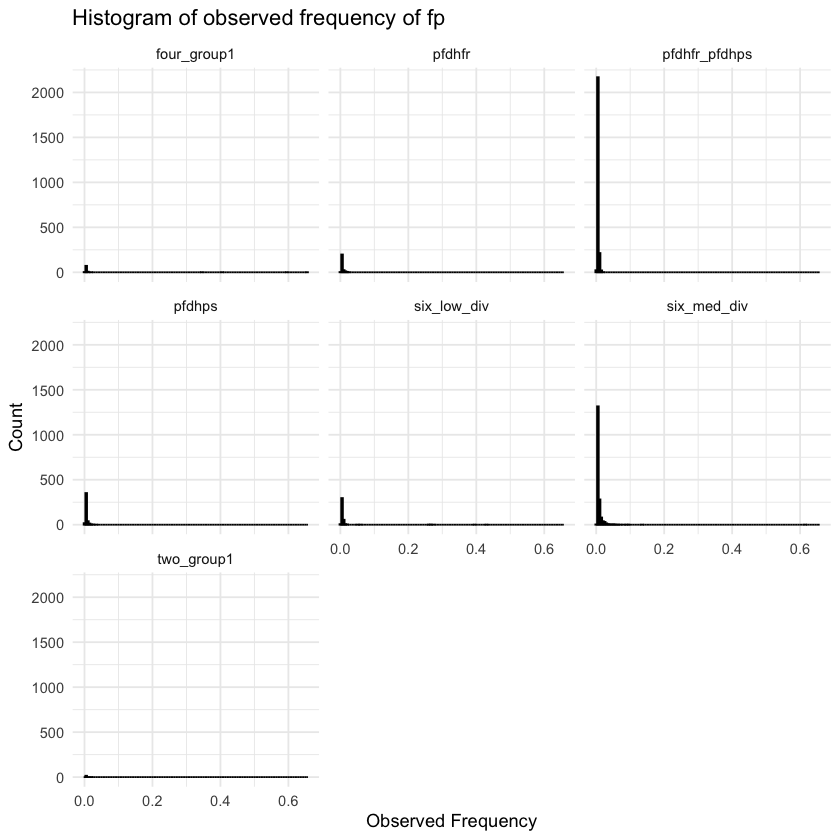

In [37]:
# Filter rows where classification is "fp"
df_fp <- tool_results_wtruth_goodcoi %>%
  filter(classification == "fp")

# Plot histogram of obs_freq
ggplot(df_fp, aes(x = obs_freq)) +
  geom_histogram(binwidth = 0.005, fill = "steelblue", color = "black") +
  labs(
    x = "Observed Frequency",
    y = "Count",
    title = "Histogram of observed frequency of fp"
  ) +
  facet_wrap(~ group_id) +
  theme_minimal()

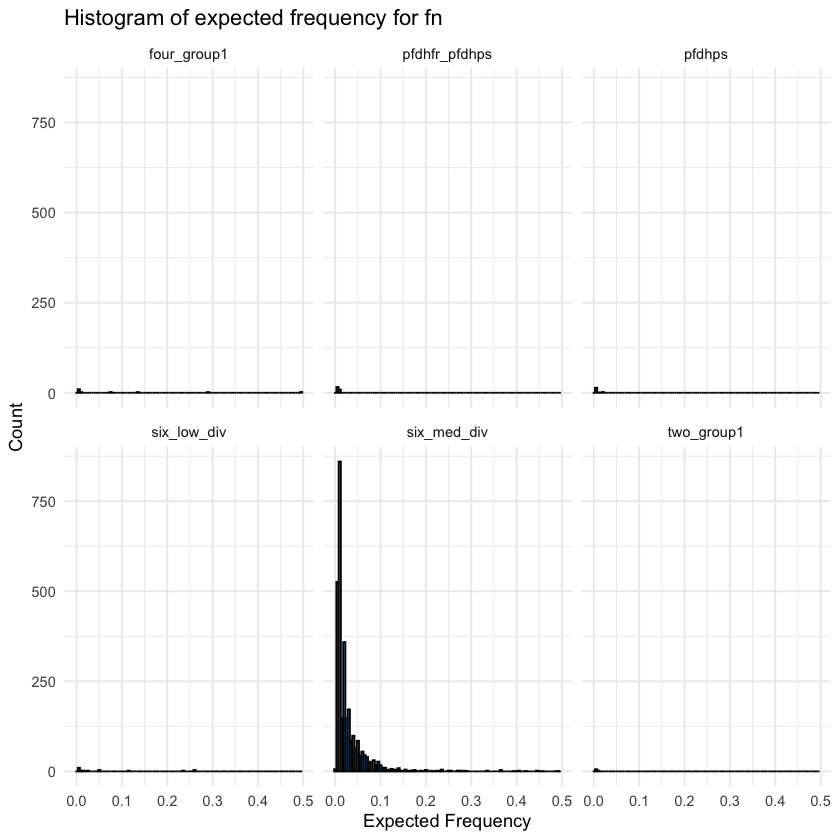

In [38]:
# Filter rows where classification is "fp"
df_fp <- tool_results_wtruth_goodcoi %>%
  filter(classification == "fn")

# Plot histogram of obs_freq
ggplot(df_fp, aes(x = exp_freq)) +
  geom_histogram(binwidth = 0.005, fill = "steelblue", color = "black") +
  labs(
    x = "Expected Frequency",
    y = "Count",
    title = "Histogram of expected frequency for fn"
  ) +
  facet_wrap(~ group_id) +
  theme_minimal()

## Classification of tp,fp,fn

In [5]:
tool_results_wtruth_goodcoi <- tool_results_wtruth_goodcoi %>%
  mutate(
    classification = case_when(
      obs_freq != 0 & exp_freq != 0 ~ "tp",  # true positive
      obs_freq != 0 & exp_freq == 0 ~ "fp",  # false positive
      obs_freq == 0 & exp_freq != 0 ~ "fn",  # false negative
      TRUE ~ NA_character_            # optional: for cases not covered above
    )
  )

In [6]:
unique(tool_results_wtruth_goodcoi$classification)

[1] "tp"

In [6]:
tool_results_wtruth_goodcoi %>% filter(is.na(obs_freq))

sim_id,paramset_id,obs_freq,obs_prev,variant,obs_n_samp,group_id,mean_coi_tool_param,exp_n_samp,exp_freq,exp_prev,country,pop_alpha,coi_r,coi_p,k_s,true_mean_coi,coi_misspec,classification
<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


### Allele Frequency

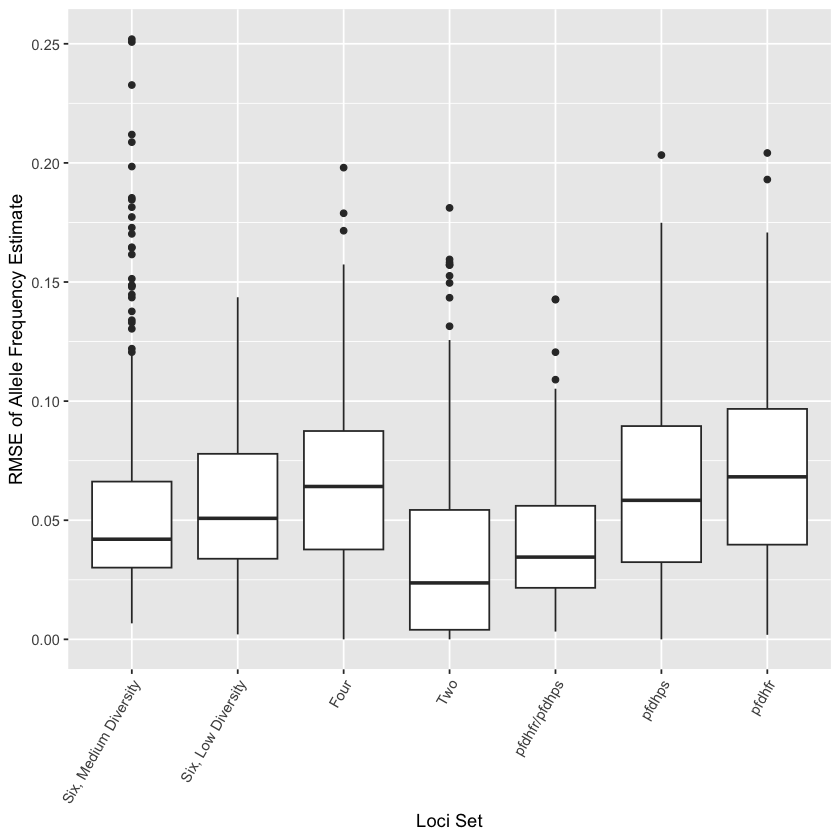

In [7]:
# Compute RMSE of frequency and prevalence -----------------------------
goodcoi_rmse <- tool_results_wtruth_goodcoi %>%
  group_by(
    sim_id, 
    paramset_id, 
    country, 
    group_id, 
    pop_alpha, 
    coi_p, 
    coi_r, 
    k_s
  ) %>%
  summarize(
    freq_rmse = sqrt(mean((obs_freq - exp_freq)^2)), 
    prev_rmse = sqrt(mean((obs_prev - exp_prev)^2)), 
    .groups = "drop"
  )

# Show all RMSEs as a boxplot ------------------------------------------
goodcoi_rmse <- goodcoi_rmse %>%
  mutate(
    group_id = factor(
      group_id, 
      c(
        "six_med_div", 
        "six_low_div", 
        "four_group1", 
        "two_group1", 
        "pfdhfr_pfdhps", 
        "pfdhps", 
        "pfdhfr"
      ), 
      labels = c(
        "Six, Medium Diversity", 
        "Six, Low Diversity", 
        "Four", 
        "Two", 
        "pfdhfr/pfdhps", 
        "pfdhps", 
        "pfdhfr"
      )
    )
  )
goodcoi_rmse %>%
  ggplot(mapping = aes(x = group_id, y = freq_rmse)) +
  geom_boxplot() +
  scale_x_discrete(
  ) +
  labs(x = "Loci Set", y = "RMSE of Allele Frequency Estimate") +
  theme(axis.text.x = element_text(angle = 60, hjust = 1))

These box plots shows the RMSE of allele frequency estimates based on all
simulations (combining different parameter sets and replicates). Different boxes
correspond to different loci sets. The median accuracy is comparable and fairly
good regardless of the number of loci tested, but there are some high outliers
for the medium diversity group of six loci.

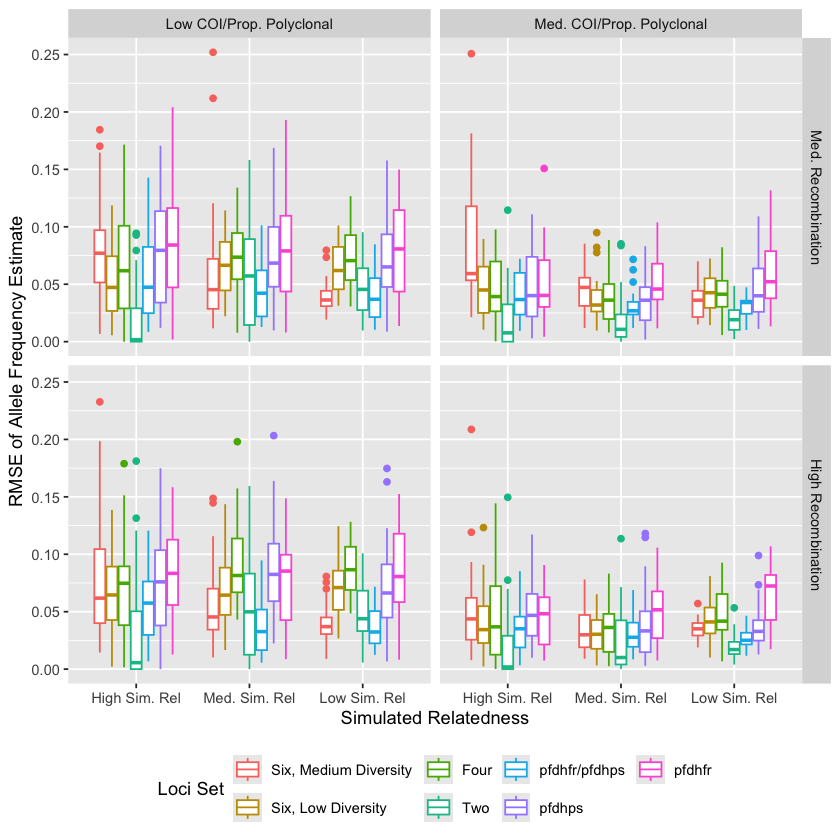

In [8]:
# Create box plots of RMSE, separated by simulation parameters ---------
goodcoi_rmse <- goodcoi_rmse %>%
  mutate(
    pop_alpha = factor(
      pop_alpha, 
      c("2.33", "9", "99"), 
      labels = c("High Sim. Rel", "Med. Sim. Rel", "Low Sim. Rel")
    )
  ) %>%
  mutate(
    k_s = factor(
      k_s, 
      c("0.5", "0.2"), 
      labels = c("Med. Recombination", "High Recombination")
    )
  ) %>%
  # coi_p was varied in synchronicity with coi_r to produce different 
  # polyclonality levels, and thus coi_p is implicitly included when 
  # using coi_r as a plotting aesthetic
  mutate(
    coi_r = factor(
      coi_r, 
      c("0.25", "0.5"), 
      labels = c("Low COI/Prop. Polyclonal", "Med. COI/Prop. Polyclonal")
    )
  )
goodcoi_rmse %>%
  ggplot(mapping = aes(x = pop_alpha, y = freq_rmse, color = group_id)) +
  geom_boxplot() +
  facet_grid(rows = vars(k_s), cols = vars(coi_r)) +
  labs(
    x = "Simulated Relatedness", 
    y = "RMSE of Allele Frequency Estimate", 
    color = "Loci Set"
  ) +
  theme(legend.position = "bottom")

These box plots also show allele frequency RMSE, but separated out in terms of
the simulation parameters, which affected the between-sample relatedness, the
COI, and the rate of recombination.

These results show that accuracy improves as between-sample relatedness
declines. Also, accuracy tends to be higher in the medium COI condition. The
relationship between accuracy and group size is not straightforward: the two
loci group tends to have the best accuracy, but the six loci, medium diversity
group sometimes has the worst accuracy and sometimes the best.

### Sample Prevalence

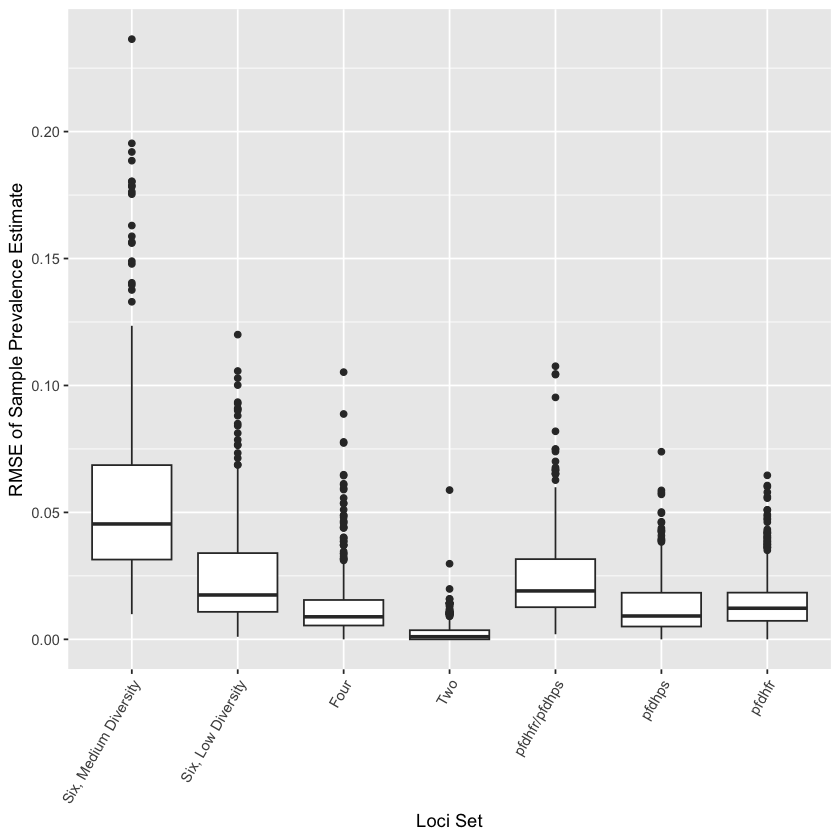

In [9]:
# Show all RMSEs as a boxplot ------------------------------------------
goodcoi_rmse %>%
  ggplot(mapping = aes(x = group_id, y = prev_rmse)) +
  geom_boxplot() +
  scale_x_discrete(
  ) +
  labs(x = "Loci Set", y = "RMSE of Sample Prevalence Estimate") +
  theme(axis.text.x = element_text(angle = 60, hjust = 1))

This box plot shows the RMSE of sample prevalence estimates based on all
simulations (combining different parameter sets and replicates). Different boxes
correspond to different loci sets. The accuracy of these estimates is generally
pretty good, except for the six loci, medium diversity group.

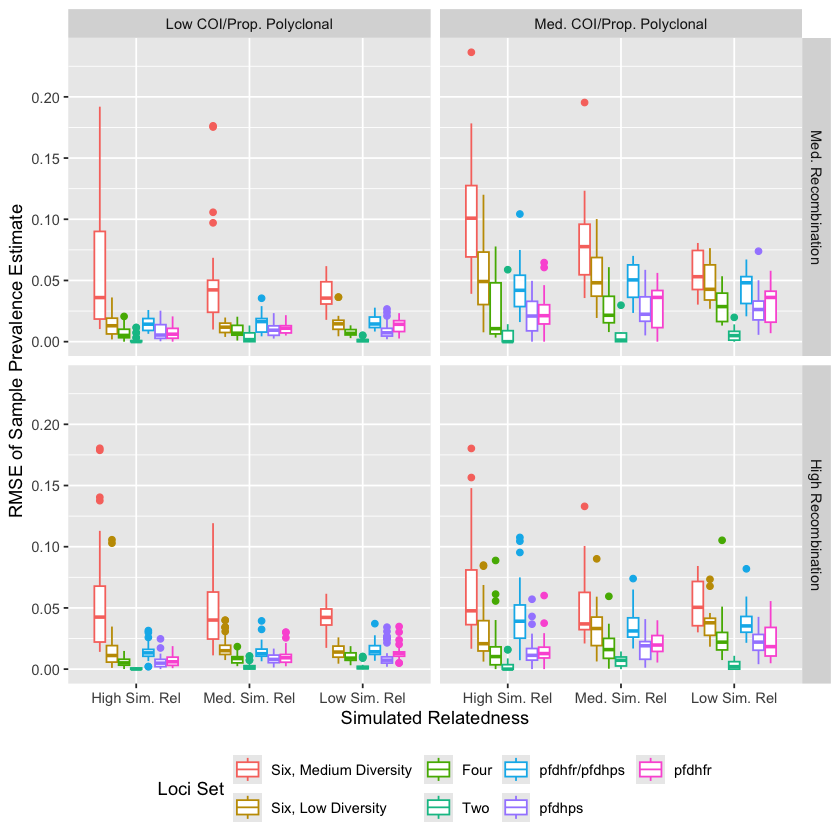

In [10]:
# Create box plots of RMSE, separated by simulation parameters ---------
goodcoi_rmse %>%
  ggplot(mapping = aes(x = pop_alpha, y = prev_rmse, color = group_id)) +
  geom_boxplot() +
  facet_grid(rows = vars(k_s), cols = vars(coi_r)) +
  labs(
    x = "Simulated Relatedness", 
    y = "RMSE of Sample Prevalence Estimate", 
    color = "Loci Set"
  ) +
  theme(legend.position = "bottom")

These box plots also show sample prevalence RMSE, but separated out in terms of
the simulation parameters, which affected the between-sample relatedness, the
COI, and the rate of recombination.

The accuracy of the prevalence estimates tends to be very good in the low COI
simulations, except in the six loci, medium diversity group noted above.
Accuracy is still pretty good in the medium COI condition, and very good for the
two loci group. The level of recombination doesn't seem to have a big effect.

## Summary and Next Steps

These results show that FEM does fairly well at estimating allele frequencies,
and quite well at estimating sample prevalence. Accuracy is notably worse in the
six loci, medium diversity group. Testing larger and more diverse loci groups
would be a valuable next step. Also, the relationships observed between allele
frequency RMSE and simulation parameters did not always make sense. Further
investigation would be a good idea. Finally, calculating RMSE for all alleles in
each loci group may mask poor performance estimating the frequencies of
individual alleles, particularly low frequency alleles. Additional investigation
into the accuracy of low frequency allele estimates, to begin to establish
thresholds of detection, is advised.